In [1]:
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

In [3]:
X = iris.data
y = iris.target

In [4]:
type(y)

numpy.ndarray

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.4, random_state=1)

In [7]:
X_test.shape

(60, 4)

In [8]:
from sklearn.neighbors import KNeighborsClassifier

In [9]:
knn = KNeighborsClassifier(n_neighbors=3)

In [10]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [11]:
previsione = knn.predict(X_test)

In [12]:
from sklearn import metrics

In [13]:
metrics.accuracy_score(previsione, y_test)

0.9833333333333333

In [14]:
from sklearn.model_selection import cross_val_score

In [15]:
score = cross_val_score(knn, X, y, cv = 10, scoring="accuracy")

In [16]:
score

array([1.        , 0.93333333, 1.        , 0.93333333, 0.86666667,
       1.        , 0.93333333, 1.        , 1.        , 1.        ])

In [17]:
score.mean()

0.9666666666666666

In [18]:
score.std()

0.04472135954999579

In [19]:
scores = []
for i in range(1, 31): 
    knn = KNeighborsClassifier(n_neighbors=i)
    score = cross_val_score(knn, X, y, cv = 10, scoring="accuracy")
    mi = score.mean()
    scores.append(mi)

In [20]:
import matplotlib.pyplot as plt

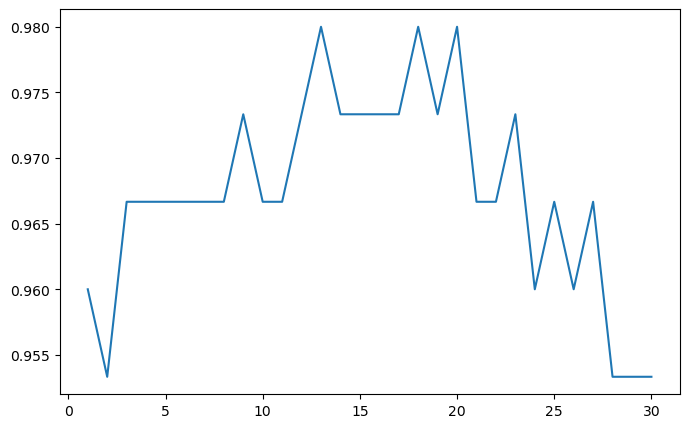

In [21]:
plt.figure(figsize= (8, 5))
plt.plot(range(1, 31), scores)
plt.show()

#### Uso GridSearchCV per trovare i parametri ottimi

In [22]:
from sklearn.model_selection import GridSearchCV

In [23]:
k_range = list(range(1, 31))

In [24]:
print(k_range)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]


In [25]:
param_grid = {'n_neighbors': k_range}
param_grid

{'n_neighbors': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30]}

In [26]:
grid = GridSearchCV(knn, param_grid, cv = 5, scoring="accuracy")

In [27]:
grid

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=30),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='accuracy')

In [28]:
grid.fit(X, y)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=30),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30]},
             scoring='accuracy')

In [29]:
import pandas as pd
data_grid = pd.DataFrame(grid.cv_results_)

In [30]:
data_grid

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.000794,4.454413e-04,0.002948,1.155220e-03,1,{'n_neighbors': 1},0.966667,0.966667,0.933333,0.933333,1.0,0.960000,0.024944,19
1,0.000328,8.389470e-05,0.001560,4.914800e-04,2,{'n_neighbors': 2},0.966667,0.933333,0.933333,0.900000,1.0,0.946667,0.033993,26
2,0.000268,3.115079e-05,0.001144,9.248301e-05,3,{'n_neighbors': 3},0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,10
3,0.000232,1.494228e-05,0.001078,1.561174e-04,4,{'n_neighbors': 4},0.966667,0.966667,0.966667,0.966667,1.0,0.973333,0.013333,6
4,0.000270,1.971155e-05,0.001175,1.146173e-04,5,{'n_neighbors': 5},0.966667,1.000000,0.933333,0.966667,1.0,0.973333,0.024944,6
5,0.000286,6.743910e-05,0.001130,9.366162e-05,6,{'n_neighbors': 6},0.966667,1.000000,0.966667,0.966667,1.0,0.980000,0.016330,1
6,0.000220,1.426803e-05,0.000979,4.698973e-05,7,{'n_neighbors': 7},0.966667,1.000000,0.966667,0.966667,1.0,0.980000,0.016330,1
7,0.000204,3.066623e-06,0.000908,2.077642e-05,8,{'n_neighbors': 8},0.966667,1.000000,0.933333,0.933333,1.0,0.966667,0.029814,10
8,0.000184,7.381587e-06,0.000845,5.019784e-05,9,{'n_neighbors': 9},0.966667,1.000000,0.966667,0.933333,1.0,0.973333,0.024944,6
9,0.000175,3.502076e-06,0.000773,1.631494e-05,10,{'n_neighbors': 10},0.966667,1.000000,1.000000,0.933333,1.0,0.980000,0.026667,1


In [31]:
dati_scoring = data_grid[["params", "mean_test_score", "std_test_score", "rank_test_score"]]

In [32]:
dati_scoring.sort_values("rank_test_score")

,params,mean_test_score,std_test_score,rank_test_score
10,{'n_neighbors': 11},0.980000,0.026667,1
5,{'n_neighbors': 6},0.980000,0.016330,1
6,{'n_neighbors': 7},0.980000,0.016330,1
9,{'n_neighbors': 10},0.980000,0.026667,1
11,{'n_neighbors': 12},0.980000,0.026667,1
3,{'n_neighbors': 4},0.973333,0.013333,6
4,{'n_neighbors': 5},0.973333,0.024944,6
8,{'n_neighbors': 9},0.973333,0.024944,6
12,{'n_neighbors': 13},0.973333,0.024944,6
18,{'n_neighbors': 19},0.966667,0.029814,10


### Use the RandomForest 

In [33]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

n_estimators = [100, 150, 200, 250, 300]
max_features = [10, 20, 30, 40]
max_depth = [5, 10, 15, 20]

In [34]:
# Create the random grid
random_grid = {
               'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth
              }

In [35]:
grid = GridSearchCV(clf, random_grid, cv = 5, scoring="accuracy")

In [36]:
grid.fit(X, y)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [5, 10, 15, 20],
                         'max_features': [10, 20, 30, 40],
                         'n_estimators': [100, 150, 200, 250, 300]},
             scoring='accuracy')

In [37]:
import pandas as pd
data_grid = pd.DataFrame(grid.cv_results_)

In [38]:
data_grid

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.041226,0.014082,0.001760,0.000290,5,10,100,"{'max_depth': 5, 'max_features': 10, 'n_estima...",0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,1
1,0.050586,0.000471,0.002384,0.000155,5,10,150,"{'max_depth': 5, 'max_features': 10, 'n_estima...",0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,1
2,0.069050,0.004093,0.003010,0.000062,5,10,200,"{'max_depth': 5, 'max_features': 10, 'n_estima...",0.966667,0.966667,0.900000,0.966667,1.0,0.960000,0.032660,62
3,0.085476,0.004837,0.003718,0.000088,5,10,250,"{'max_depth': 5, 'max_features': 10, 'n_estima...",0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,1
4,0.100233,0.000435,0.004408,0.000049,5,10,300,"{'max_depth': 5, 'max_features': 10, 'n_estima...",0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,0.033587,0.000110,0.001584,0.000006,20,40,100,"{'max_depth': 20, 'max_features': 40, 'n_estim...",0.966667,0.966667,0.933333,0.933333,1.0,0.960000,0.024944,69
76,0.050135,0.000309,0.002278,0.000015,20,40,150,"{'max_depth': 20, 'max_features': 40, 'n_estim...",0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,1
77,0.066949,0.000300,0.002954,0.000014,20,40,200,"{'max_depth': 20, 'max_features': 40, 'n_estim...",0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,1
78,0.083612,0.000320,0.003640,0.000020,20,40,250,"{'max_depth': 20, 'max_features': 40, 'n_estim...",0.966667,0.966667,0.933333,0.966667,1.0,0.966667,0.021082,1


In [39]:
dati_scoring = data_grid[["params", "mean_test_score", "std_test_score", "rank_test_score"]]

In [40]:
dati_scoring.sort_values("rank_test_score")

,params,mean_test_score,std_test_score,rank_test_score
0,"{'max_depth': 5, 'max_features': 10, 'n_estima...",0.966667,0.021082,1
53,"{'max_depth': 15, 'max_features': 30, 'n_estim...",0.966667,0.021082,1
52,"{'max_depth': 15, 'max_features': 30, 'n_estim...",0.966667,0.021082,1
51,"{'max_depth': 15, 'max_features': 30, 'n_estim...",0.966667,0.021082,1
50,"{'max_depth': 15, 'max_features': 30, 'n_estim...",0.966667,0.021082,1
...,...,...,...,...
20,"{'max_depth': 10, 'max_features': 10, 'n_estim...",0.953333,0.033993,76
58,"{'max_depth': 15, 'max_features': 40, 'n_estim...",0.953333,0.033993,76
42,"{'max_depth': 15, 'max_features': 10, 'n_estim...",0.953333,0.033993,76
5,"{'max_depth': 5, 'max_features': 20, 'n_estima...",0.953333,0.033993,76
